## BUS2003 Assignment 2 – Data Pipeline & Analysis

This notebook aims to perform a data pipeline and analysis on the Dubai property sales dataset. The purpose is to extract, clean, and analyse the data to gain meaningful insights.

Overall, the process follows an ETL (Extract, Transform, Load) pipeline. The dataset is first loaded and explored, then cleaned and prepared for analysis. Finally, the data is analysed using various techniques and visualisations to identify patterns and trends.

### 1.1 Extract

In this section, the dataset is loaded into the notebook and an initial exploration is performed. This includes examining the structure of the data, such as the number of rows and columns, the data types of each column, and identifying any missing values.

Preliminary observations are also made regarding the overall data quality to determine any potential issues that may need to be addressed in later stages of the pipeline.

## 1.1 Extract, the section loads and examines the dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("dubai_property_sales.csv")

## Display of First couple rows of datasets
This code prints the first 10 rows of the  Dubai Property Sales dataset, before cleaning.

In [2]:
print(df.head(10))

  transaction_number     transaction_date transaction_type  \
0         102-1-2023  2023-01-02 07:25:49            Sales   
1        102-10-2023  2023-01-02 08:06:49            Sales   
2       102-100-2023  2023-01-02 09:01:22            Sales   
3      102-1000-2023  2023-01-05 13:26:06            Sales   
4     102-10000-2023  2023-03-01 16:02:19            Sales   
5     102-10001-2023  2023-03-01 16:09:42            Sales   
6     102-10002-2023  2023-03-01 19:41:51            Sales   
7     102-10003-2023  2023-03-01 19:45:13            Sales   
8     102-10004-2023  2023-03-01 19:51:18            Sales   
9     102-10005-2023  2023-03-01 19:52:42            Sales   

      transaction_sub_type registration_type is_free_hold        usage  \
0  Sell - Pre registration          Off-Plan    Free Hold  Residential   
1  Sell - Pre registration          Off-Plan    Free Hold  Residential   
2  Sell - Pre registration          Off-Plan    Free Hold  Residential   
3  Sell - Pre registr

## Dataset Shape
Examines the rows and columns in the dataset

In [3]:
print(f"Shape: {df.shape}\n")

Shape: (81601, 22)



## Variable Names
Display all column names within the dataset.

In [4]:
print(f"Columns: {df.columns}\n")

Columns: Index(['transaction_number', 'transaction_date', 'transaction_type',
       'transaction_sub_type', 'registration_type', 'is_free_hold', 'usage',
       'area', 'property_type', 'property_sub_type', 'amount',
       'transaction_size_sqm', 'property_size_sqm', 'room', 'parking',
       'nearest_metro', 'nearest_mall', 'nearest_landmark', 'no_of_buyer',
       'no_of_seller', 'master_project', 'project'],
      dtype='object')



### Variable Types
Examines the data types of variables

In [5]:
print(f"Data Types: {df.dtypes}")

Data Types: transaction_number       object
transaction_date         object
transaction_type         object
transaction_sub_type     object
registration_type        object
is_free_hold             object
usage                    object
area                     object
property_type            object
property_sub_type        object
amount                  float64
transaction_size_sqm    float64
property_size_sqm       float64
room                     object
parking                  object
nearest_metro            object
nearest_mall             object
nearest_landmark         object
no_of_buyer               int64
no_of_seller              int64
master_project           object
project                  object
dtype: object


### Missing Values
Highlights the number and percentage of missing values inside columns.

In [6]:
print(f"Missing Values per Column: {df.isnull().sum()}\n")
print(f"Percentage of Missing Values per Column: {(df.isnull().sum() / len(df)) * 100}\n")

Missing Values per Column: transaction_number          0
transaction_date            0
transaction_type            0
transaction_sub_type        0
registration_type           0
is_free_hold                0
usage                       0
area                        0
property_type               0
property_sub_type        1159
amount                      0
transaction_size_sqm      483
property_size_sqm         408
room                    15019
parking                 23764
nearest_metro           27042
nearest_mall            27101
nearest_landmark        17716
no_of_buyer                 0
no_of_seller                0
master_project          81487
project                 17723
dtype: int64

Percentage of Missing Values per Column: transaction_number       0.000000
transaction_date         0.000000
transaction_type         0.000000
transaction_sub_type     0.000000
registration_type        0.000000
is_free_hold             0.000000
usage                    0.000000
area                

### Duplicate Rows
Calculates the total amount of duplicate entries inside the dataset.

In [7]:
print(f"How many Duplicate Rows Exist: {df.duplicated().sum()}\n")

How many Duplicate Rows Exist: 808



### Statistics Summary
Displays the basic data and value ranges for numerical variables inside the dataset

In [8]:
print(f"Statistics: {df.describe()}\n")

Statistics:              amount  transaction_size_sqm  property_size_sqm   no_of_buyer  \
count  8.160100e+04          8.111800e+04       8.119300e+04  81601.000000   
mean   3.124265e+06          7.265520e+02       7.511700e+02      0.874903   
std    2.145941e+07          6.925276e+04       6.926878e+04      0.634149   
min    5.700000e+01          0.000000e+00       6.430000e+00      0.000000   
25%    7.250000e+05          6.788000e+01       6.851000e+01      0.000000   
50%    1.440000e+06          1.061500e+02       1.077800e+02      1.000000   
75%    2.596020e+06          1.865850e+02       1.882300e+02      1.000000   
max    3.869204e+09          1.886678e+07       1.886678e+07     12.000000   

       no_of_seller  
count  81601.000000  
mean       0.822747  
std        0.737429  
min        0.000000  
25%        0.000000  
50%        1.000000  
75%        1.000000  
max       29.000000  



### Categories
Identifies the various categories inside important categorical variables.

In [9]:
print(f"Categories: {df['no_of_seller'].unique()}\n")

Categories: [ 1  3  2  6  4  5  7  0 11 10  8  9 29 18 14 13 16 17 24 20 19 12 15 22
 23]



### Extract Summary
The raw Dubai Property Sales dataset was loaded and successfully examined. The CSV file includes 22 variables related to real estate transactions in Dubai including transaction details, property attributes and location-based data. The majority of variables are saved as objects, highlighting categorical data, while some variables like no_of_seller and no_of_buyer are integer-based. Multiple data quality issues were discovered during the initial exploration. Numerous location-based variables such as nearest_mall and property-related variables like property_size_sqm are missing a major proportion of values. 808 rows of duplicates were identified, potentially affecting the reliability of the analysis if they aren't addressed. The above results demonstrate that further cleaning and transformation is necessary in the next step of the ETL pipeline to make the dataset precise and reliable for further analysis.

### 1.2 Transform

In this section, the dataset is being cleaned, validated and prepared for downstream use.

Transformation includes: Removing Duplicates, Handling Missing Values, Dropping high-missing columns if forced, fill missing numeric values, fill missing text values, resolve inconsistent data, convert numeric formats, normalise data formats, normalise numeric formats, normalise column names, examine unrealistic values, filter for insufficient records, reassess missing values, reassess duplicate values.

## Removal of Duplicate Rows
This code performs the removal of duplicate rows from the dataset.

In the original dataset, the duplicates was causing the analysis to be repeating records and mapping redundant values multiple times. After removing the duplicates, the dataset has decreased the size and deleted redundant records. Consequently, this makes the dataset more accurate and reliable for further transformation and analysis as duplicates are prevented.

In [10]:
print(f"How many Duplicate Rows Exist: {df.duplicated().sum()}\n")

How many Duplicate Rows Exist: 808



In [11]:
df = df.drop_duplicates()

In [12]:
counted_duplicates = df.duplicated().sum()

print(f"Number of Duplicate Rows: {counted_duplicates}")

Number of Duplicate Rows: 0


### Handling Missing Values

Missing numerical values were populated with the mean to ensure the accuracy and reliability of the dataset. Absent categorical records were substituted with "Unknown" to enusre accuracy and coherence.


In [13]:
print(f"Missing Values per Column: {df.isnull().sum()}\n")
print(f"Percentage of Missing Values per Column: {(df.isnull().sum() / len(df)) * 100}\n")

Missing Values per Column: transaction_number          0
transaction_date            0
transaction_type            0
transaction_sub_type        0
registration_type           0
is_free_hold                0
usage                       0
area                        0
property_type               0
property_sub_type        1159
amount                      0
transaction_size_sqm      248
property_size_sqm         407
room                    14372
parking                 23076
nearest_metro           26785
nearest_mall            26860
nearest_landmark        17478
no_of_buyer                 0
no_of_seller                0
master_project          80679
project                 17271
dtype: int64

Percentage of Missing Values per Column: transaction_number       0.000000
transaction_date         0.000000
transaction_type         0.000000
transaction_sub_type     0.000000
registration_type        0.000000
is_free_hold             0.000000
usage                    0.000000
area                

In [14]:
df = df.drop(columns=["master_project"])

In [15]:
df['transaction_size_sqm'] = df['transaction_size_sqm'].fillna(df['transaction_size_sqm'].mean())
df['property_size_sqm'] = df['property_size_sqm'].fillna(df['property_size_sqm'].mean())

In [16]:
df['property_sub_type'] = df['property_sub_type'].fillna('Unknown')
df['room'] = df['room'].fillna('Unknown')
df['parking'] = df['parking'].fillna('Unknown')
df['nearest_metro'] = df['nearest_metro'].fillna('Unknown')
df['nearest_mall'] = df['nearest_mall'].fillna('Unknown')
df['nearest_landmark'] = df['nearest_landmark'].fillna('Unknown')
df['project'] = df['project'].fillna('Unknown')

In [17]:
print(df.isnull().sum())

transaction_number      0
transaction_date        0
transaction_type        0
transaction_sub_type    0
registration_type       0
is_free_hold            0
usage                   0
area                    0
property_type           0
property_sub_type       0
amount                  0
transaction_size_sqm    0
property_size_sqm       0
room                    0
parking                 0
nearest_metro           0
nearest_mall            0
nearest_landmark        0
no_of_buyer             0
no_of_seller            0
project                 0
dtype: int64


### Fix Incoinsistent Values

In [18]:
print(df['project'].unique())

['AYKON CITY 3' 'Fern' 'SEVEN CITY JLT' ... 'THE HAVEN' 'VELA by OMNIYAT'
 'Terrazzo ']


### Converting columns to datetime format

The transaction_date column has been transformed into datetime to suppoer quantitative analysis and streamline data coherence.

In [19]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print(df['transaction_date'])

0       2023-01-02 07:25:49
1       2023-01-02 08:06:49
2       2023-01-02 09:01:22
3       2023-01-05 13:26:06
4       2023-03-01 16:02:19
                ...        
81596   2023-01-04 09:55:02
81597   2023-01-09 09:48:42
81598   2023-03-08 10:50:43
81599   2023-05-01 11:40:33
81600   2023-06-14 09:29:11
Name: transaction_date, Length: 80793, dtype: datetime64[ns]


### Convert Numeric Formats

The parking column has been transformed into a numeric data type for easier quantitative analysis and also maintains data stability. Parking represents the amount of parking spots available at an area. It also only measures measurable quantities as the data type displayed is float64. All non-numeric or parking values are being discarded because they are converted to 0 which eliminates the possibility of containing any non-numeric values. Appropriate nuemircal values are being preserved as they can be further analysed in future analysis.

In [20]:
df['parking'] = pd.to_numeric(df['parking'], errors="coerce")
df['parking'] = df['parking'].fillna(0)
print(df['parking'])

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
81596    0.0
81597    0.0
81598    0.0
81599    0.0
81600    0.0
Name: parking, Length: 80793, dtype: float64


### Standardise and Cleaning Columns

Inconsistent categorical records including the room 'Residential Flats' and others was standardised to enhance consistency across all columns.

In [21]:
# Standardising and Cleaning transaction_sub_type
df.loc[:, 'transaction_sub_type'] = df['transaction_sub_type'].str.strip().str.title().str.replace('-', ' ')
df['transaction_sub_type'].unique()
print(df['transaction_sub_type'])

# Standardising and Cleaning area
df.loc[:, 'area'] = df['area'].str.title()
df['area'].unique()
print(df['area'])

# Standardising and Cleaning property_sub_type
df['property_sub_type'] = df['property_sub_type'].replace({
   'Residential Flats': 'Flat',
})
df['property_sub_type'].unique()
print(df['property_sub_type'])

# Standardising and Cleaning Room
df['room'] = df['room'].replace({
   '2 B/R': '2 Bedroom',
   '1 B/R': '1 Bedroom',
   '3 B/R': '3 Bedroom',
   '4 B/R': '4 Bedroom',
   '5 B/R': '5 Bedroom',
   '6 B/R': '6 Bedroom',
   'PENTHOUSE': 'Penthouse',
   '1 bedroom': '1 Bedroom',
   '3 bedroom': '3 Bedroom'

})
df['room'].unique()
print(df['room'])

# Standardising and Cleaning nearest_metro
df.loc[:, 'nearest_metro'] = df['nearest_metro'].str.title()
df['nearest_metro'] = df['nearest_metro'].replace('Sharaf Dg Metro Station', 'Sharaf DG Metro Station')
df['nearest_metro'] = df['nearest_metro'].replace('Damac Properties', 'Unknown')
df['nearest_metro'].unique()
print(df['nearest_metro'])

# Standardising and Cleaning nearest_mall
df.loc[:, 'nearest_mall'] = df['nearest_mall'].str.strip().str.replace('-', ' ')
df['nearest_mall'].unique()
print(df['nearest_mall'])

# Standardising and Cleaning project
df.loc[:, 'project'] = df['project'].str.title()
df['project'].unique()
print(df['project'])


0        Sell   Pre Registration
1        Sell   Pre Registration
2        Sell   Pre Registration
3        Sell   Pre Registration
4        Sell   Pre Registration
                  ...           
81596        Delayed Development
81597        Delayed Development
81598        Delayed Development
81599        Delayed Development
81600        Delayed Development
Name: transaction_sub_type, Length: 80793, dtype: object
0                   Business Bay
1                   Business Bay
2                        Al Wasl
3          Jumeirah Lakes Towers
4        Jumeirah Village Circle
                  ...           
81596              Silicon Oasis
81597              Silicon Oasis
81598              Silicon Oasis
81599              Silicon Oasis
81600              Silicon Oasis
Name: area, Length: 80793, dtype: object
0        Flat
1        Flat
2        Flat
3        Flat
4        Flat
         ... 
81596    Flat
81597    Flat
81598    Flat
81599    Flat
81600    Flat
Name: property_sub_typ

### Checking, Fixing and Filtering out Unrealistic Values

Unrealistic values including overwhelming property sizes and zero transaction sizes were isolated from the analysis to reduce the negative impact of outliers on the transforming dataset. Filtering was implemented to segragate large unrealistic values from the analysis. A minority of outliers remain however it doesn't adversely impact the analysis of the cleaned dataset.

In [22]:
# Fix Negative Parking
df['parking'] = df['parking'].replace(-1,0)

# Remove 0 Transaction size
df = df[df['transaction_size_sqm'] > 0]

# Remove inconsistent property sizes
df = df[df['property_size_sqm'] < 1000]

# Remove incoinsistent parking values
df = df[df['parking'] < 20]



print(df.describe())

                    transaction_date        amount  transaction_size_sqm  \
count                          76375  7.637500e+04          76375.000000   
mean   2023-04-01 20:20:09.727568128  2.163499e+06            157.723858   
min              2023-01-02 06:56:17  1.000000e+02              0.660000   
25%       2023-02-20 07:21:12.500000  7.162196e+05             66.365000   
50%              2023-03-29 14:28:28  1.422069e+06            101.580000   
75%       2023-05-17 14:49:35.500000  2.450888e+06            169.640000   
max              2023-06-26 16:07:02  2.200000e+08          13038.160000   
std                              NaN  3.305404e+06            176.390445   

       property_size_sqm       parking   no_of_buyer  no_of_seller  
count       76375.000000  76375.000000  76375.000000  76375.000000  
mean          161.588382      0.364374      0.907090      0.847437  
min             6.430000      0.000000      0.000000      0.000000  
25%            67.335000      0.000000 

### Created a derived variable

A derived variable created referred to as price_per_sqm was produced by the total amount by property_size_sqm. This ensures that comparison between property values are easier to distuingish.

In [23]:
df['price_per_sqm'] = df['amount'] / df['property_size_sqm']

### Rechecking Duplicates

This analysis is ti ensure after all the cleaning that occurred there aren't any duplicates remaining.

In [24]:
df = df.drop_duplicates()

print(df.duplicated().sum())

0


### Saving Cleaned Dataset

Save the cleaned dubai_property_sales.csv dataset in the same file.

In [26]:
df.to_csv("Realestate_cleaned.csv", index=False)

### Transform Summary

The transformation stage executed the removal ofduplicate values, managing missing records, discarding the high-missing master_project column, converting data types, converting into numeric formats, standardising inconsistent columns, fixing and filtering out unrealistic values, constructing a price_per_sqm variable, re-evaluating duplicates and exporting the newly cleaned dataset.

### 1.3 Load

In this section, the dataset is being loaded, reviewed and summarised to confirm the cleaned dataset has been successfully loaded and ready for analysis.

The dataset is being loaded and reviewed to validate that the extraction and transaction process was successful. The dataset is then summarized in terms of number of rows and columns, variable names and types, outline of missing values after cleaning and category counts and descriptive statistics.

### Reload and Preview dataset

In [27]:
df = pd.read_csv("Realestate_cleaned.csv")

print(df.head(10))


  transaction_number     transaction_date transaction_type  \
0         102-1-2023  2023-01-02 07:25:49            Sales   
1        102-10-2023  2023-01-02 08:06:49            Sales   
2       102-100-2023  2023-01-02 09:01:22            Sales   
3      102-1000-2023  2023-01-05 13:26:06            Sales   
4     102-10000-2023  2023-03-01 16:02:19            Sales   
5     102-10001-2023  2023-03-01 16:09:42            Sales   
6     102-10002-2023  2023-03-01 19:41:51            Sales   
7     102-10003-2023  2023-03-01 19:45:13            Sales   
8     102-10004-2023  2023-03-01 19:51:18            Sales   
9     102-10005-2023  2023-03-01 19:52:42            Sales   

      transaction_sub_type registration_type is_free_hold        usage  \
0  Sell   Pre Registration          Off-Plan    Free Hold  Residential   
1  Sell   Pre Registration          Off-Plan    Free Hold  Residential   
2  Sell   Pre Registration          Off-Plan    Free Hold  Residential   
3  Sell   Pre Registr

### Check shape of cleaned dataset

In [28]:
print(f"Shape: {df.shape}\n")

Shape: (75323, 22)



### Summarising variable names and variable types

In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75323 entries, 0 to 75322
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_number    75323 non-null  object 
 1   transaction_date      75323 non-null  object 
 2   transaction_type      75323 non-null  object 
 3   transaction_sub_type  75323 non-null  object 
 4   registration_type     75323 non-null  object 
 5   is_free_hold          75323 non-null  object 
 6   usage                 75323 non-null  object 
 7   area                  75323 non-null  object 
 8   property_type         75323 non-null  object 
 9   property_sub_type     75323 non-null  object 
 10  amount                75323 non-null  float64
 11  transaction_size_sqm  75323 non-null  float64
 12  property_size_sqm     75323 non-null  float64
 13  room                  75323 non-null  object 
 14  parking               75323 non-null  float64
 15  nearest_metro      

### Summary of missing values after cleaning

In [30]:
print(f"Miss values after cleaning: {df.isnull().sum()}")

Miss values after cleaning: transaction_number      0
transaction_date        0
transaction_type        0
transaction_sub_type    0
registration_type       0
is_free_hold            0
usage                   0
area                    0
property_type           0
property_sub_type       0
amount                  0
transaction_size_sqm    0
property_size_sqm       0
room                    0
parking                 0
nearest_metro           0
nearest_mall            0
nearest_landmark        0
no_of_buyer             0
no_of_seller            0
project                 0
price_per_sqm           0
dtype: int64


### Summary of basic descriptive statistics

In [31]:
print(f"Statistics of dataset after cleaning: {df.describe()}\n")

Statistics of dataset after cleaning:              amount  transaction_size_sqm  property_size_sqm       parking  \
count  7.532300e+04          75323.000000       75323.000000  75323.000000   
mean   2.180397e+06            158.268307         162.186805      0.369463   
std    3.324252e+06            177.382182         172.880355      0.600324   
min    1.000000e+02              0.660000           6.430000      0.000000   
25%    7.290125e+05             66.190000          67.135000      0.000000   
50%    1.430743e+06            101.450000         102.740000      0.000000   
75%    2.483932e+06            169.910000         172.630000      1.000000   
max    2.200000e+08          13038.160000         999.900000     19.000000   

        no_of_buyer  no_of_seller  price_per_sqm  
count  75323.000000  75323.000000   75323.000000  
mean       0.919759      0.859273   15550.195912  
std        0.610671      0.699075   11272.349329  
min        0.000000      0.000000       0.676727  
25% 

### Summary of category Counts

In [32]:
print(df['room'].value_counts())
print()
print(df['transaction_type'].value_counts())
print()
print(df['property_type'].value_counts())


room
1 Bedroom      22762
2 Bedroom      15564
Studio         10906
Unknown        10697
3 Bedroom       9328
4 Bedroom       3339
Office          1682
Shop             653
5 Bedroom        299
Penthouse         60
6 Bedroom         23
Single Room        8
GYM                2
Name: count, dtype: int64

transaction_type
Sales       59278
Mortgage    12655
Gifts        3390
Name: count, dtype: int64

property_type
Unit        58103
Land         9973
Building     7247
Name: count, dtype: int64


### Load Summary

The cleaned dataset has been successfully loaded, reviewed, demonstrates an overview of variable names and types, displays a summary of missing values in columns, exhibits basic descriptive statistics and outlines the category counts. The cleaned dataset is now prepared for analysis.

### 2.1 Exploration of Analysing how property prices vary across different subtypes and discussion of observations with supporting evidence from the analysis

### Grouped Summary statistics to examine differences in sale amounts throghout  property subtypes

In [33]:
grouped_summary_statistics = df.groupby('property_sub_type')['amount'].describe()

print(grouped_summary_statistics)

                                      count          mean           std  \
property_sub_type                                                         
Airport                                99.0  5.086417e+06  3.394373e+06   
Clinic                                  3.0  1.897429e+06  5.336957e+05   
Commercial                           2764.0  4.877222e+06  8.211186e+06   
Commercial / Offices / Residential      1.0  1.520000e+07           NaN   
Flat                                51975.0  1.846736e+06  3.013322e+06   
General Use                            79.0  9.323901e+06  3.706362e+06   
Government Housing                    198.0  1.234931e+06  1.263483e+06   
Gymnasium                               2.0  1.589300e+06  0.000000e+00   
Hotel Apartment                      2085.0  2.292729e+06  3.441211e+06   
Hotel Rooms                          1162.0  1.344378e+06  1.086910e+06   
Industrial                             35.0  4.485727e+06  3.881689e+06   
Land                     

### Box Plot to analyse outliers, spread and price distribution throughout property sub types

<Figure size 1400x800 with 0 Axes>

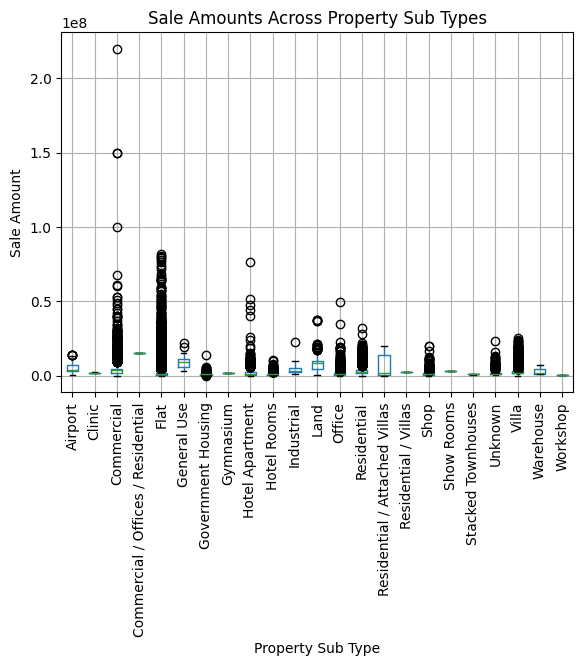

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
df.boxplot(column='amount', by='property_sub_type')
plt.title('Sale Amounts Across Property Sub Types')
plt.suptitle('')
plt.xlabel('Property Sub Type')
plt.ylabel('Sale Amount')
plt.xticks(rotation=90)
plt.show()

### Bar chart to examine average sale prices across property subtypes

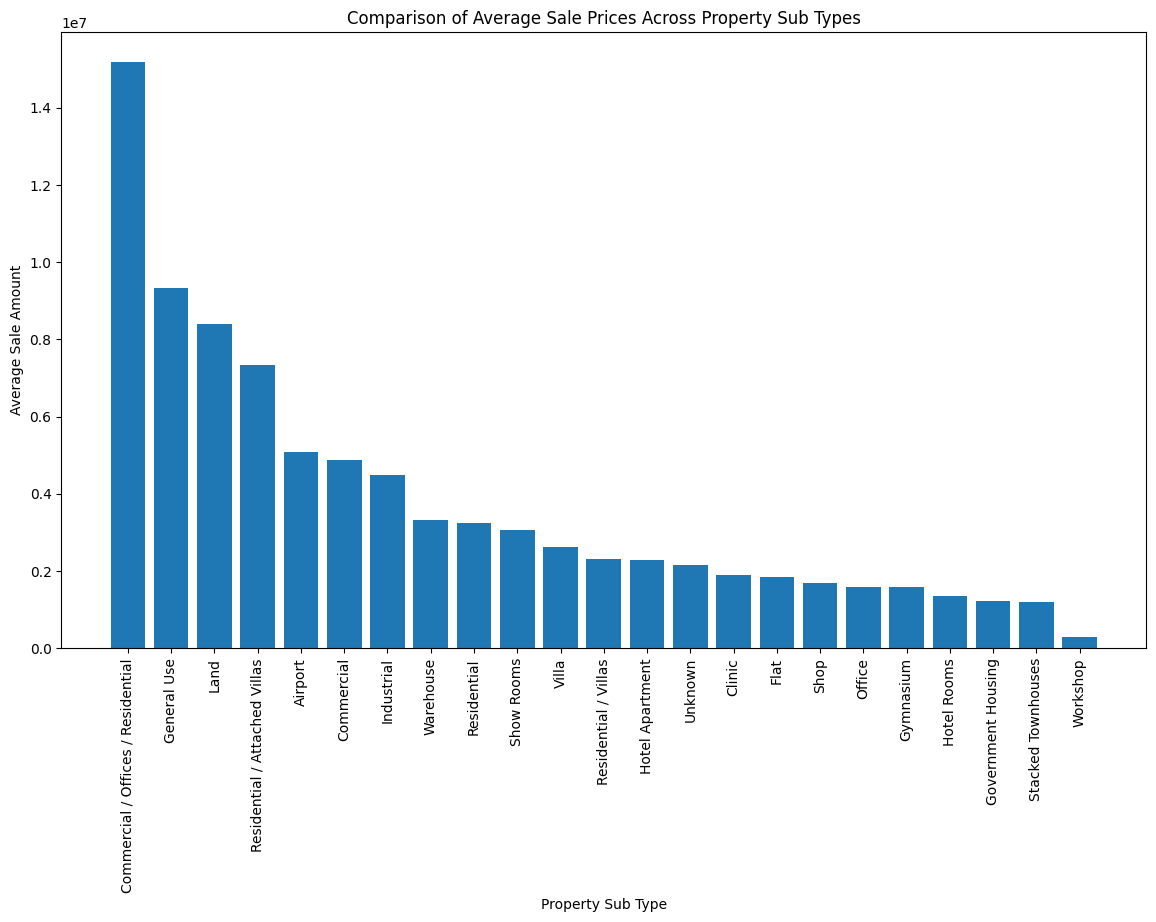

In [35]:
average_sale_prices = df.groupby('property_sub_type')['amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))
plt.bar(average_sale_prices.index, average_sale_prices.values)
plt.title('Comparison of Average Sale Prices Across Property Sub Types')
plt.xlabel('Property Sub Type')
plt.ylabel('Average Sale Amount')
plt.xticks(rotation=90)
plt.show()

### Discussion of observations

The general trend of the analyais on the relationship between property subtype and sale amount is that the sale amounts fluctuate throughout various property subtypes. A proporotion of property subtypes have routinely larger average sales prices compared to the rest. A wide range of pricing distributions is displayed by the grouped statistics and box plot. Property subtypes such as Commercial/Offices/Residential output the largest sale amount. General use, Land and Residential/Attached villas record the second biggest average sales amount. The above mentioned subtypes underline extensive property categories. Subtypes such as Workshop, Stacked Townhouses and Government Housing record the lowest average sales amount. These property types a more reasonably priced and may have lower market worth. Property subtypes such as Flat, Commercial and Hotel Apartment, have greater disparity of pricing compared to others. Transaction peicing differs greatly between residential and commerocial columns. Extended whiskers and wider boxplots demonstrate increased pricing variability inside the columns. Property subtypes such as Commercial, Hotel Apartment and Office include significant outliers. Subtypes including Flat and Commercial display an above-average sales, compared to the others. According to the output of the boxplot, Flat conducts the highest number of transactions, though there average price isn't the biggest. The bar chart appears positively skewed, indicating that there is a positive trend. Subtypes including Residential/Villas, Gymnasium and Clinic record the smallest sales transactions, which could potentially be unreliable and lead to further inaccurate analysis.

### 2.2 Exploration of Evaluating hw property sale prices vary across different areas in dubai. Are there specific areas where prices are consistently higher or lower compared to others? Analyse the data to identify pricing patterns across areas to explain your findings with supporting evidence from the dataset.

### Grouped Summary statistics to examine differences in sale prices across different areas

In [36]:
grouped_summary_statistics = df.groupby('area')['amount'].describe()

print(grouped_summary_statistics)

                count          mean           std        min        25%  \
area                                                                      
Abu Hail         26.0  1.135816e+06  7.159089e+05    82320.0   382500.0   
Akoya Oxygen    113.0  1.258789e+06  4.915135e+05   390000.0   975000.0   
Al Aweer First  198.0  9.572197e+05  3.050887e+05   100000.0   750000.0   
Al Bada          20.0  5.627982e+06  5.823859e+06   250000.0  2075000.0   
Al Baraha         3.0  2.933333e+06  2.003331e+06  1400000.0  1800000.0   
...               ...           ...           ...        ...        ...   
Wadi Al Safa 7  151.0  6.273620e+05  2.905687e+05   209648.0   459000.0   
Wadi Alshabak     2.0  1.000000e+06  0.000000e+00  1000000.0  1000000.0   
Warsan First    290.0  7.207507e+05  2.525537e+05   310000.0   480000.0   
Zaabeel First   113.0  8.344012e+06  6.087004e+06  4216000.0  4696000.0   
Zaabeel Second  230.0  2.737988e+06  1.092335e+06   350000.0  2000000.0   

                      50

### Bar chart to examine average sale prices across different areas

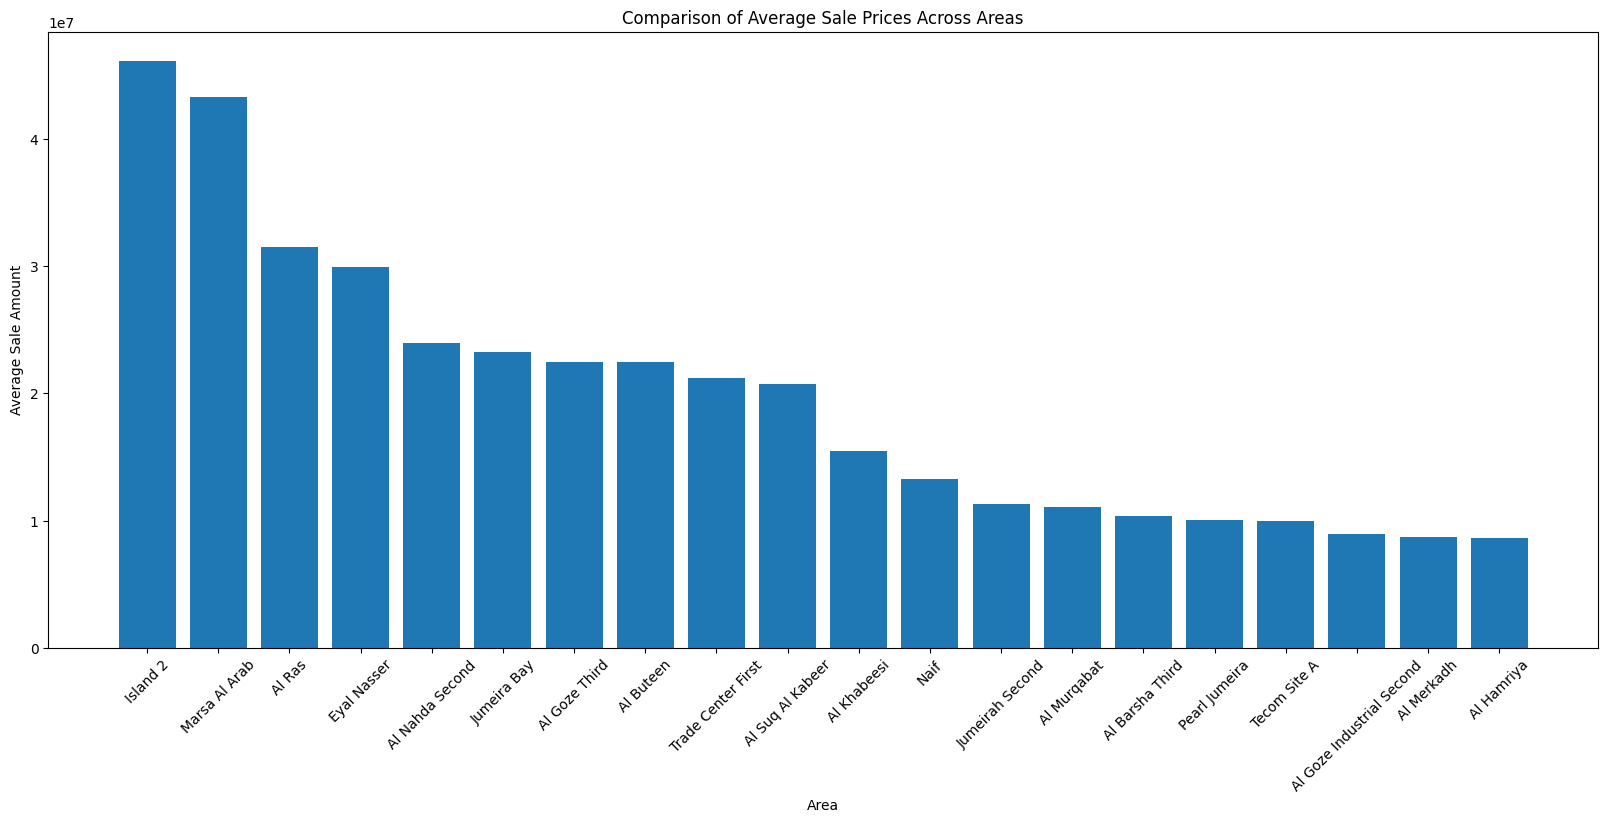

In [37]:
average_sale_prices = df.groupby('area')['amount'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(20,8))
plt.bar(average_sale_prices.index, average_sale_prices.values)
plt.title('Comparison of Average Sale Prices Across Areas')
plt.xlabel('Area')
plt.ylabel('Average Sale Amount')
plt.xticks(rotation=45)
plt.show()

### Box Plot to analyse outliers, spread and variation within areas

<Figure size 1400x800 with 0 Axes>

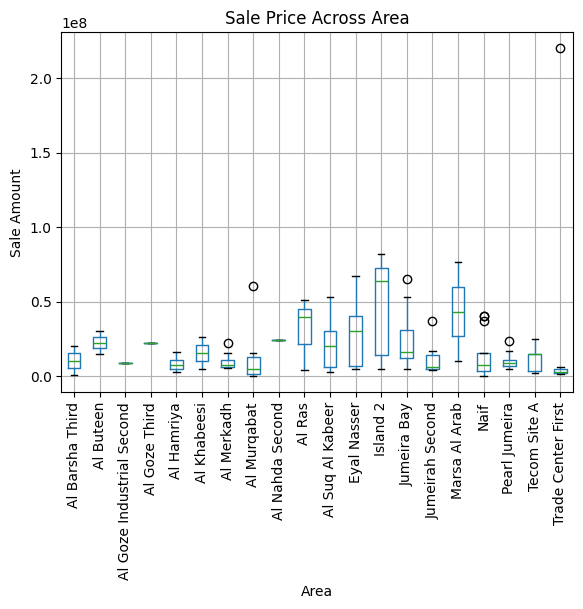

In [38]:
average_sale_prices = df.groupby('area')['amount'].mean().sort_values(ascending=False).head(20).index
df_filtered = df[df['area'].isin(average_sale_prices)]

plt.figure(figsize=(14,8))
df_filtered.boxplot(column='amount', by='area')
plt.title('Sale Price Across Area')
plt.suptitle('')
plt.xlabel('Area')
plt.ylabel('Sale Amount')
plt.xticks(rotation=90)
plt.show()

### Discussion of observations

The general trend of property sales prices varying across different areas in Dubai is that sale prices fluctuate theoughout all of the areas. High-price areas such as Island 2, Marsa Al Arab and Al Ras, contain the highest number of sales prices. This indicates that higher-priced areas are usually displayed in the bigger interquartile stages. Lower-priced areas such as Al Hamriya, Pearl Jumeria and Al Barsha Third contain the lowest number of sale prices. This indicates that the majority lower-priced areas have a smaller spread of prices, reducing the potential for outliers. Areas such as Zabeel First and Al Baraha have mean values that are larger than its median values thus directing premoum-value transactions. This leads ton the dataset being positively skewed. Areas such as Wadi Al Safa 7,  Al Bada and Warsan First have lower median property prices, potentially increasing the chances of data quality issues. Areas such as Al Murqabat, Jumeira Bay and Naif tend to have broad pricing ranges, due to a more elongated spread. Furthermore, the filtering for the top 20 areas in Dubai is successful, hence improves reliability and consistency of data visualisations and comparisons.